# Análisis CLTV histórico — Fase 5

| Campo | Valor |
|---|---|
| Fuente | `marts.customer_360` |
| Clientes esperados | 5 750 |
| Ground truth | SUM(cltv) = 3 670 369,64 € |
| Referencia técnica | D-CLTV-05, D-CLTV-13 |

**Estructura**

| Sección | Contenido |
|---|---|
| 0 | Carga y validación de datos |
| 1 | Estadística descriptiva de CLTV |
| 2 | Curva de Lorenz y coeficiente de Gini |
| 3 | Correlaciones Spearman |
| 4 | Análisis geográfico |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../src").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from scipy import stats

from etl.db import get_engine

CLTV_GT   = 3_670_369.64
N_CLIENTES = 5_750

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

def fmt_eur(x: float, decimales: int = 2) -> str:
    s = f"{x:,.{decimales}f}"
    return s.replace(",", "_").replace(".", ",").replace("_", ".") + " €"

def fmt_pct(x: float, decimales: int = 1) -> str:
    return f"{x * 100:.{decimales}f} %"

def guardar_figura(nombre: str) -> None:
    ruta = FIG_DIR / nombre
    plt.savefig(ruta, bbox_inches="tight")
    print(f"  -> {ruta}")

## Seccion 0 — Carga y validacion de datos

In [2]:
engine = get_engine()

with engine.connect() as conn:
    df = pd.read_sql(
        text("SELECT * FROM marts.customer_360 ORDER BY customer_id"),
        conn,
    )

cols_float = [
    "cltv", "ingresos_brutos", "ingresos_netos",
    "margen_bruto_total", "margen_neto",
    "importe_devuelto_total", "costo_devuelto_total",
    "aov", "margin_rate", "freq_mensual", "return_rate",
]
df[cols_float] = df[cols_float].astype(float)

cols_date = ["fecha_alta_efectiva", "primera_compra", "ultima_compra"]
for col in cols_date:
    df[col] = pd.to_datetime(df[col])

print(f"Filas: {len(df):,}  |  Columnas: {len(df.columns)}")

Filas: 5,750  |  Columnas: 28


In [3]:
with engine.connect() as _conn:
    cltv_sql = float(
        _conn.execute(text("SELECT SUM(cltv) FROM marts.customer_360")).scalar()
    )
assert cltv_sql == CLTV_GT
cltv_sum = df["cltv"].sum()
assert abs(cltv_sum - CLTV_GT) < 0.01
assert len(df) == N_CLIENTES
criticas = [
    "customer_id", "zona_id", "anio_alta", "fecha_alta_efectiva",
    "primera_compra", "ultima_compra", "meses_activo", "recency_dias",
    "n_pedidos", "n_items_vendidos", "n_items_devueltos",
    "ingresos_brutos", "importe_devuelto_total", "ingresos_netos",
    "margen_bruto_total", "costo_devuelto_total", "margen_neto",
    "aov", "freq_mensual", "return_rate", "cltv",
]
assert df[criticas].isnull().sum().sum() == 0
assert df["margin_rate"].isnull().sum() == 0
drift = abs(cltv_sum - cltv_sql)
print(f"SQL SUM(cltv) = {fmt_eur(cltv_sql)}  OK")
print(f"df  SUM(cltv) = {fmt_eur(cltv_sum)}  OK  (drift: {drift:.2e} EUR)")
print("Seccion 0 OK")

SQL SUM(cltv) = 3.670.369,64 €  OK
df  SUM(cltv) = 3.670.369,64 €  OK  (drift: 4.66e-10 EUR)
Seccion 0 OK


## Seccion 1 — Estadistica descriptiva de CLTV

Percentiles CLTV:
Percentil      Valor
       p5     0,00 €
      p25    24,00 €
      p50    52,00 €
      p75   120,00 €
      p90 3.555,35 €
      p95 4.787,35 €
      p99 6.316,63 €
    p99.5 6.728,52 €
      max 9.429,44 €

Estadisticos:
  Media                      638,33 €
  Mediana                    52,00 €
  Desv. Estandar             1.555,44 €
  Skewness (Fisher)         2.5655  [>0 sesgo derecha; normal=0]
  Excess kurtosis           5.3706  [>0 colas pesadas; normal=0]

  306 clientes con cltv <= 0 (5.3 %) excluidos del histograma log.



  -> ..\reports\figures\5_1_distribucion_cltv.png


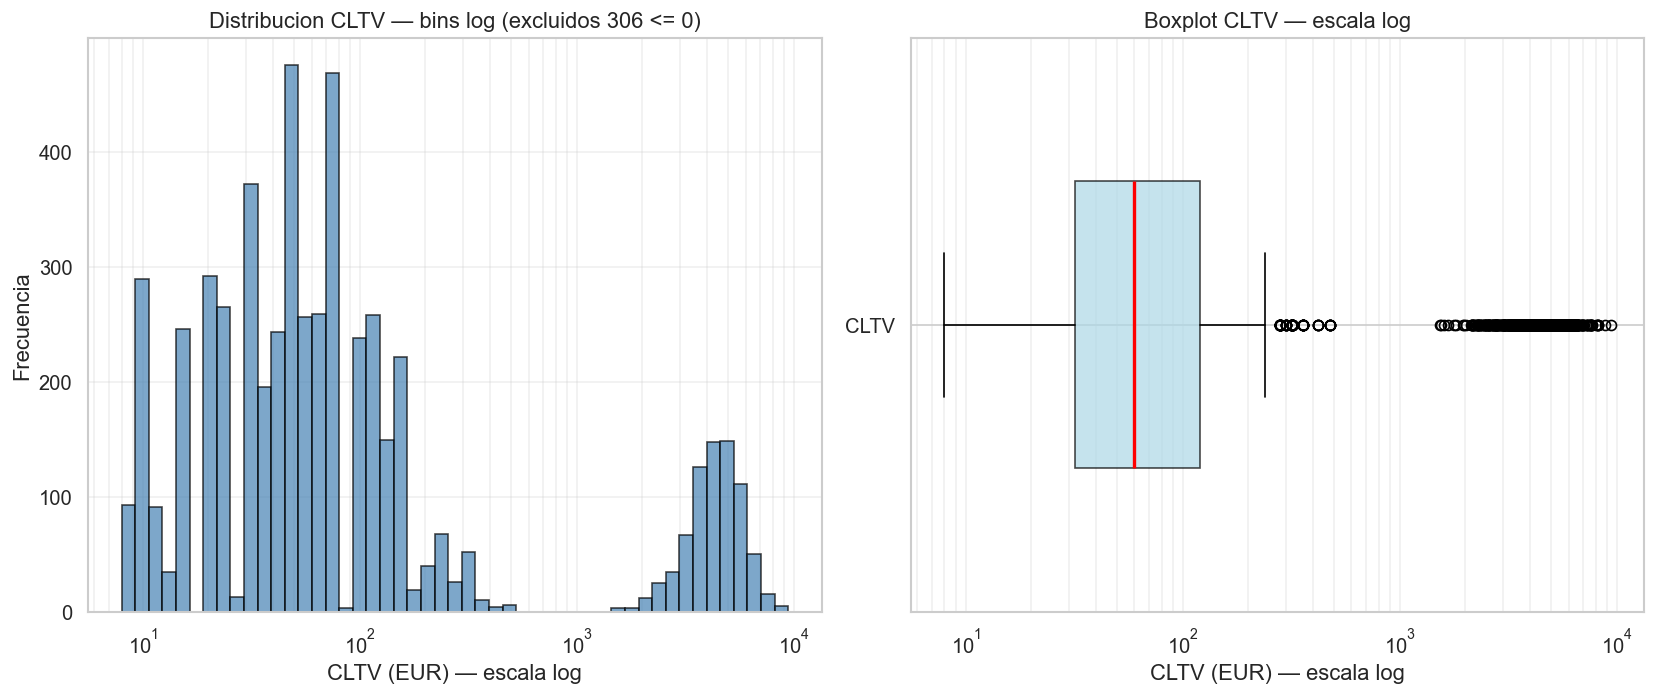

In [4]:
# ── Percentiles ───────────────────────────────────────────────────────────────
percentiles = [5, 25, 50, 75, 90, 95, 99, 99.5]
values = np.percentile(df['cltv'], percentiles)
df_perc = pd.DataFrame({
    'Percentil': [f'p{int(p) if p == int(p) else p}' for p in percentiles] + ['max'],
    'Valor': [fmt_eur(v) for v in values] + [fmt_eur(df['cltv'].max())],
})
print("Percentiles CLTV:")
print(df_perc.to_string(index=False))
print()

# ── Estadisticos ─────────────────────────────────────────────────────────────
# bias=False: correccion de muestra (n-1). Para n=5750 diferencia negligible
# pero es la convencion estadistica correcta (SPSS, R).
# stats.kurtosis: EXCESS kurtosis (= momento4/sigma4 - 3). Normal -> 0.
media   = df['cltv'].mean()
mediana = df['cltv'].median()
std     = df['cltv'].std()
SKEWNESS_CLTV = stats.skew(df['cltv'], bias=False)
kurt_cltv     = stats.kurtosis(df['cltv'], bias=False)

print("Estadisticos:")
print(f"  Media                      {fmt_eur(media)}")
print(f"  Mediana                    {fmt_eur(mediana)}")
print(f"  Desv. Estandar             {fmt_eur(std)}")
print(f"  Skewness (Fisher)     {SKEWNESS_CLTV:>10.4f}  [>0 sesgo derecha; normal=0]")
print(f"  Excess kurtosis       {kurt_cltv:>10.4f}  [>0 colas pesadas; normal=0]")
print()

# ── cltv <= 0 ─────────────────────────────────────────────────────────────────
n_no_pos = (df['cltv'] <= 0).sum()
cltv_pos = df.loc[df['cltv'] > 0, 'cltv']
if n_no_pos > 0:
    print(f"  {n_no_pos} clientes con cltv <= 0 ({fmt_pct(n_no_pos / len(df))}) excluidos del histograma log.")
else:
    print(f"  Todos los clientes tienen cltv > 0.")
print()

# ── Visualizaciones ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))

ax1 = plt.subplot(1, 2, 1)
bins = np.logspace(np.log10(cltv_pos.min()), np.log10(cltv_pos.max()), 50)
ax1.hist(cltv_pos, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xscale('log')
ax1.set_xlabel('CLTV (EUR) — escala log')
ax1.set_ylabel('Frecuencia')
titulo = 'Distribucion CLTV — bins log'
if n_no_pos > 0:
    titulo += f' (excluidos {n_no_pos} <= 0)'
ax1.set_title(titulo)
ax1.grid(True, alpha=0.3, which='both')

ax2 = plt.subplot(1, 2, 2)
ax2.boxplot([cltv_pos], vert=False, widths=0.5, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_xscale('log')
ax2.set_xlabel('CLTV (EUR) — escala log')
ax2.set_yticklabels(['CLTV'])
ax2.set_title('Boxplot CLTV — escala log')
ax2.grid(True, alpha=0.3, axis='x', which='both')

plt.tight_layout()
guardar_figura('5_1_distribucion_cltv.png')
plt.show()

In [5]:
# ── Verificacion bimodalidad ──────────────────────────────────────────────────
print("Distribucion de n_pedidos:")
print(df['n_pedidos'].describe())

print("\nCorrelacion Spearman n_pedidos vs cltv:")
print(df[['n_pedidos', 'cltv']].corr(method='spearman'))

alto = df['cltv'] > 1000
print(f"\nClientes con CLTV > 1000 EUR:  {alto.sum():>5}  ({fmt_pct(alto.sum()/len(df))})")
print(f"  n_pedidos medio:     {df.loc[alto, 'n_pedidos'].mean():>8.1f}")
print(f"  meses_activo medio:  {df.loc[alto, 'meses_activo'].mean():>8.1f}")

bajo = df['cltv'] <= 1000
print(f"\nClientes con CLTV <= 1000 EUR: {bajo.sum():>5}  ({fmt_pct(bajo.sum()/len(df))})")
print(f"  n_pedidos medio:     {df.loc[bajo, 'n_pedidos'].mean():>8.1f}")
print(f"  meses_activo medio:  {df.loc[bajo, 'meses_activo'].mean():>8.1f}")

Distribucion de n_pedidos:
count    5750.000000
mean        3.478261
std         6.585678
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        34.000000
Name: n_pedidos, dtype: float64

Correlacion Spearman n_pedidos vs cltv:
           n_pedidos      cltv
n_pedidos   1.000000  0.584664
cltv        0.584664  1.000000

Clientes con CLTV > 1000 EUR:    750  (13.0 %)
  n_pedidos medio:         20.0
  meses_activo medio:      17.4

Clientes con CLTV <= 1000 EUR:  5000  (87.0 %)
  n_pedidos medio:          1.0
  meses_activo medio:       1.0


In [6]:
# ── Subgrupo cltv <= 0: compradores-devolvedores ──────────────────────────────
no_pos = df[df['cltv'] <= 0]
print(f"Clientes con CLTV <= 0: {len(no_pos)}")
print(f"\nEstadisticos del subgrupo CLTV <= 0:")
print(no_pos[['cltv', 'n_pedidos', 'n_items_devueltos',
              'return_rate', 'margen_bruto_total',
              'importe_devuelto_total']].describe())
print(f"\n¿Cuantos tienen n_items_devueltos > 0?")
print((no_pos['n_items_devueltos'] > 0).sum())

Clientes con CLTV <= 0: 306

Estadisticos del subgrupo CLTV <= 0:
             cltv  n_pedidos  n_items_devueltos  return_rate  \
count  306.000000      306.0         306.000000   306.000000   
mean    -2.646797        1.0           1.029412     0.977124   
std     12.162289        0.0           0.273024     0.149752   
min    -80.000000        1.0           0.000000     0.000000   
25%      0.000000        1.0           1.000000     1.000000   
50%      0.000000        1.0           1.000000     1.000000   
75%      0.000000        1.0           1.000000     1.000000   
max      0.000000        1.0           2.000000     1.000000   

       margen_bruto_total  importe_devuelto_total  
count          306.000000              306.000000  
mean            44.186928              117.076373  
std             39.198962               94.337431  
min            -80.000000                0.000000  
25%             16.990000               49.900000  
50%             35.960000               89.94

In [7]:
# ── Subgrupo raro: cltv <= 0 SIN devoluciones ─────────────────────────────────
# Dato observado: margen_bruto_total es NEGATIVO (-40 o -80 EUR) con
# ingresos_brutos positivos (19.99 o 39.98 EUR).
# Coste implicito: 19.99 + 40 = 59.99 EUR (coste 3x el precio de venta).
# Son productos vendidos a perdida estructural, no productos a coste=precio.
# D-CLTV-12: se conservan en el dataset.
raros = df[(df['cltv'] <= 0) & (df['n_items_devueltos'] == 0)]
print(f"Clientes con cltv <= 0 y n_items_devueltos = 0: {len(raros)}")
print(raros[['customer_id', 'cltv', 'n_pedidos',
             'ingresos_brutos', 'margen_bruto_total',
             'importe_devuelto_total']].to_string(index=False))

Clientes con cltv <= 0 y n_items_devueltos = 0: 7
 customer_id  cltv  n_pedidos  ingresos_brutos  margen_bruto_total  importe_devuelto_total
        2191 -80.0          1            39.98               -80.0                     0.0
        2811 -40.0          1            19.99               -40.0                     0.0
        3188 -40.0          1            19.99               -40.0                     0.0
        4073 -80.0          1            39.98               -80.0                     0.0
        4656 -80.0          1            39.98               -80.0                     0.0
        4892 -40.0          1            19.99               -40.0                     0.0
        5390 -40.0          1            19.99               -40.0                     0.0


### Hallazgos clave de Seccion 1

La distribucion del CLTV en este dataset **no** es log-normal con cola larga
(distribucion tipica en retail general), sino **bimodal** con dos poblaciones
casi disjuntas:

| Grupo | n | % | n_pedidos medio | meses_activo medio |
|---|---|---|---|---|
| Compra unica (CLTV <= 1000 EUR) | 5 000 | 87,0 % | 1,0 | 1,0 |
| Recurrentes (CLTV > 1000 EUR) | 750 | 13,0 % | 20,0 | 17,4 |

La distribucion de `n_pedidos` es degenerada: p25 = p50 = p75 = 1. El 75% de los
clientes tiene exactamente 1 pedido. Esto explica el skewness moderado (2,57):
no hay una cola Pareto continua, sino dos modos discretos.

**Subgrupo compradores-devolvedores** (299 clientes dentro de los 306 con CLTV <= 0):  
Compraron una vez y devolvieron casi todo (`return_rate` medio 0,977).  
El margen bruto es positivo pero el importe devuelto es mayor, generando CLTV negativo.

**Subgrupo productos a perdida** (7 clientes, cltv <= 0 sin devoluciones):  
CLTV negativo por `margen_bruto_total` negativo estructural (dos SKUs con
coste ~3x el precio de venta: 19,99 EUR vendido con coste ~59,99 EUR,
y 39,98 EUR vendido con coste ~119,98 EUR). No son errores de datos: el
ingreso es real y positivo; el margen es negativo por diseno del producto.
D-CLTV-12: se conservan en el dataset.

**Implicaciones:**
- El Gini de CLTV sera alto: el 87% de clientes genera una fraccion
  minima del valor total.
- El clustering de Fase 6 deberia identificar al menos estos dos modos como
  clusters naturales.
- La correlacion Spearman n_pedidos vs CLTV = 0,585 (alta pero no perfecta)
  indica heterogeneidad real: hay clientes con muchos pedidos pero CLTV bajo
  (productos baratos) y clientes con pocos pedidos pero CLTV alto (AOV elevado).

## Seccion 2 — Curva de Lorenz y coeficiente de Gini

El coeficiente de Gini cuantifica la concentracion de la distribucion de CLTV.
Un Gini = 1 significa que un solo cliente acumula todo el valor; Gini = 0 es
distribucion perfectamente uniforme.

$$G = 1 - 2 \int_0^1 L(F)\,dF \approx 1 - \sum_{i=0}^{n-1}(F_{i+1}-F_i)(L_{i+1}+L_i)$$

Se calculan tres Ginis sobre subconjuntos distintos:

| Variable | Subconjunto | n esperado | Conexion con Sec. 1 |
|---|---|---|---|
| `cltv` | cltv > 0 | 5 444 | Excluye 306 compradores-devolvedores y productos a perdida |
| `margen_bruto_total` | margen_bruto > 0 | 5 743 | Excluye 7 productos a perdida estructural |
| `ingresos_brutos` | todos | 5 750 | Sin exclusiones; siempre positivo |

In [8]:
def calcular_gini(valores):
    v = np.sort(np.asarray(valores, dtype=float))
    if (v < 0).any():
        raise ValueError("calcular_gini requiere valores >= 0")
    n = len(v)
    total = v.sum()
    if n == 0 or total == 0:
        return float('nan')
    F = np.concatenate([[0.0], np.arange(1, n + 1) / n])
    L = np.concatenate([[0.0], np.cumsum(v) / total])
    # Formula explicita — sin np.trapz (deprecated NumPy 2.0)
    area = 0.5 * np.sum((F[1:] - F[:-1]) * (L[1:] + L[:-1]))
    return float(1.0 - 2.0 * area)


def _gini_rango(valores):
    # G = 2·Σ(i·vᵢ)/(n·Σv) − (n+1)/n
    # Algebraicamente identica a calcular_gini() para paso uniforme.
    # Diferencia esperada: ~1e-14 (epsilon maquina).
    v = np.sort(np.asarray(valores, dtype=float))
    n = len(v)
    total = v.sum()
    if n == 0 or total == 0:
        return float('nan')
    ranks = np.arange(1, n + 1, dtype=float)
    return float(2.0 * np.dot(ranks, v) / (n * total) - (n + 1) / n)

In [9]:
n_excl_cltv   = (df['cltv'] <= 0).sum()
n_excl_margen = (df['margen_bruto_total'] <= 0).sum()
cltv_pos_vals   = df.loc[df['cltv'] > 0, 'cltv'].values
margen_pos_vals = df.loc[df['margen_bruto_total'] > 0, 'margen_bruto_total'].values
ingresos_vals   = df['ingresos_brutos'].values

print("Subconjuntos:")
print(f"  cltv > 0:           {len(cltv_pos_vals):>5}  (excluidos: {n_excl_cltv})")
print(f"  margen_bruto > 0:   {len(margen_pos_vals):>5}  (excluidos: {n_excl_margen})")
print(f"  ingresos_brutos:    {len(ingresos_vals):>5}  (todos)")
print()

GINI_CLTV     = calcular_gini(cltv_pos_vals)
GINI_MARGEN   = calcular_gini(margen_pos_vals)
GINI_INGRESOS = calcular_gini(ingresos_vals)

print(f"Gini CLTV (cltv > 0):           {GINI_CLTV:.6f}")
print(f"Gini Margen bruto (> 0):        {GINI_MARGEN:.6f}")
print(f"Gini Ingresos brutos (todos):   {GINI_INGRESOS:.6f}")
print()
print(f"Orden: GINI_CLTV {'>' if GINI_CLTV > GINI_MARGEN else '<='} GINI_MARGEN {'>' if GINI_MARGEN > GINI_INGRESOS else '<='} GINI_INGRESOS")

Subconjuntos:
  cltv > 0:            5444  (excluidos: 306)
  margen_bruto > 0:    5743  (excluidos: 7)
  ingresos_brutos:     5750  (todos)

Gini CLTV (cltv > 0):           0.829763
Gini Margen bruto (> 0):        0.834282
Gini Ingresos brutos (todos):   0.835141

Orden: GINI_CLTV <= GINI_MARGEN <= GINI_INGRESOS


In [10]:
print("Verificacion cruzada (trap vs rango, diferencia esperada ~1e-14):")
for label, vals in [
    ("cltv",            cltv_pos_vals),
    ("margen_bruto",    margen_pos_vals),
    ("ingresos_brutos", ingresos_vals),
]:
    g_trap = calcular_gini(vals)
    g_rng  = _gini_rango(vals)
    diff   = abs(g_trap - g_rng)
    status = "OK" if diff < 1e-10 else "FAIL"
    print(f"  {label:<18}  trap={g_trap:.10f}  rango={g_rng:.10f}  |diff|={diff:.2e}  {status}")
print()
print("Seccion 2 OK")

Verificacion cruzada (trap vs rango, diferencia esperada ~1e-14):
  cltv                trap=0.8297628860  rango=0.8297628860  |diff|=6.66e-16  OK
  margen_bruto        trap=0.8342821909  rango=0.8342821909  |diff|=9.99e-16  OK
  ingresos_brutos     trap=0.8351409815  rango=0.8351409815  |diff|=1.11e-15  OK

Seccion 2 OK


Puntos Pareto del CLTV positivo (n=5444):
  Top 6.0% genera 50% del CLTV
  Top 11.0% genera 80% del CLTV
  Modo alto (cltv>1000):  91.5%
  Modo bajo (cltv<=1000): 8.5%
  -> ..\reports\figures\5_2_lorenz_cltv.png


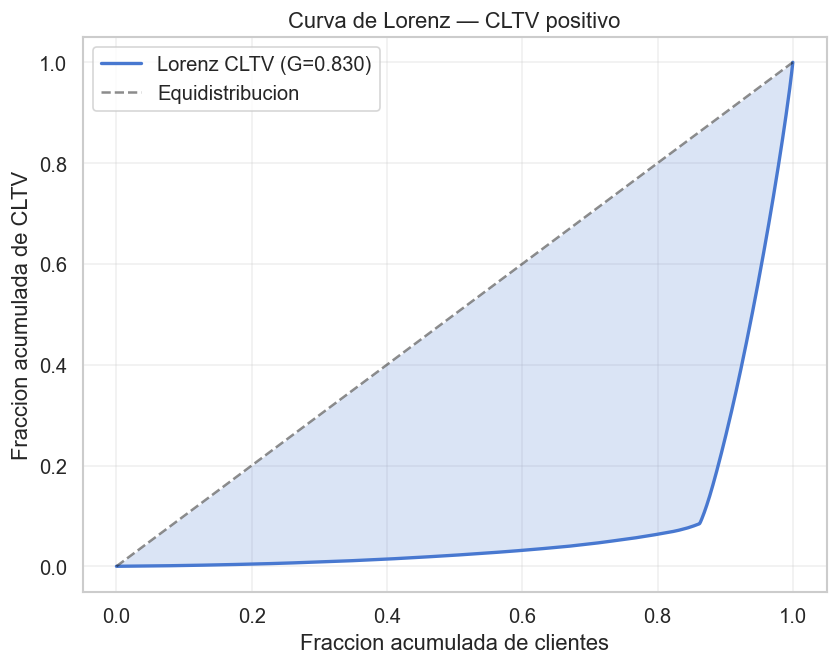

In [11]:
# ── Puntos Pareto ─────────────────────────────────────────────────────────────
v = np.sort(cltv_pos_vals)[::-1]
total = v.sum()
acum = np.cumsum(v) / total
idx_50 = np.searchsorted(acum, 0.50) + 1
idx_80 = np.searchsorted(acum, 0.80) + 1
n = len(v)

pct_top_50 = idx_50 / n * 100
pct_top_80 = idx_80 / n * 100

cltv_alto = df.loc[df['cltv'] >  1000, 'cltv'].sum()
cltv_bajo = df.loc[(df['cltv'] > 0) & (df['cltv'] <= 1000), 'cltv'].sum()
total_pos = cltv_alto + cltv_bajo
pct_alto = cltv_alto / total_pos * 100
pct_bajo = cltv_bajo / total_pos * 100

print(f"Puntos Pareto del CLTV positivo (n={n}):")
print(f"  Top {pct_top_50:.1f}% genera 50% del CLTV")
print(f"  Top {pct_top_80:.1f}% genera 80% del CLTV")
print(f"  Modo alto (cltv>1000):  {pct_alto:.1f}%")
print(f"  Modo bajo (cltv<=1000): {pct_bajo:.1f}%")

# ── Curva de Lorenz CLTV ──────────────────────────────────────────────────────
v_asc = np.sort(cltv_pos_vals)
F = np.concatenate([[0], np.arange(1, len(v_asc) + 1) / len(v_asc)])
L = np.concatenate([[0], np.cumsum(v_asc) / v_asc.sum()])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(F, L, 'b-', linewidth=2, label=f'Lorenz CLTV (G={GINI_CLTV:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Equidistribucion')
ax.fill_between(F, F, L, alpha=0.2)
ax.set_xlabel('Fraccion acumulada de clientes')
ax.set_ylabel('Fraccion acumulada de CLTV')
ax.set_title('Curva de Lorenz — CLTV positivo')
ax.legend()
ax.grid(True, alpha=0.3)
guardar_figura('5_2_lorenz_cltv.png')
plt.show()

### Hallazgos Seccion 2

- **3 Ginis ≈ 0,83** (CLTV 0,830; margen 0,834; ingresos 0,835).
  Equivalentes; pequenas diferencias por subconjuntos, no por la
  variable subyacente.
- **Pareto extremo**: top 6% genera el 50% del CLTV; top 11% genera el 80%.
  El modo alto (13% recurrentes) aporta el 91,5% del CLTV positivo;
  el modo bajo (87% transaccionales) solo el 8,5%. Confirma cuantitativamente
  la bimodalidad estructural identificada en Seccion 1.
- **Concentracion alta pero no Pareto continua**: Gini 0,83 por bimodalidad
  disjunta, no por cola larga. La curva de Lorenz muestra el quiebre
  caracteristico en torno al percentil 87.
- **Verificacion numerica**: implementacion trapezoidal vs formula de rangos
  coinciden con diferencia ≈ 1e-15 (epsilon maquina).

## Seccion 3 — Correlaciones Spearman

Spearman en lugar de Pearson porque `skewness(CLTV) = 2,57` (calculado en
Sec. 1 con `bias=False`) invalida el supuesto de normalidad marginal que
requiere Pearson para ser optimo. Spearman es robusto a distribuciones
asimetricas y a la bimodalidad documentada en S1.

Variables analizadas: `recency_dias`, `meses_activo`, `n_pedidos`, `aov`,
`margin_rate`, `return_rate`, `cltv`.

  -> ..\reports\figures\5_3_spearman.png


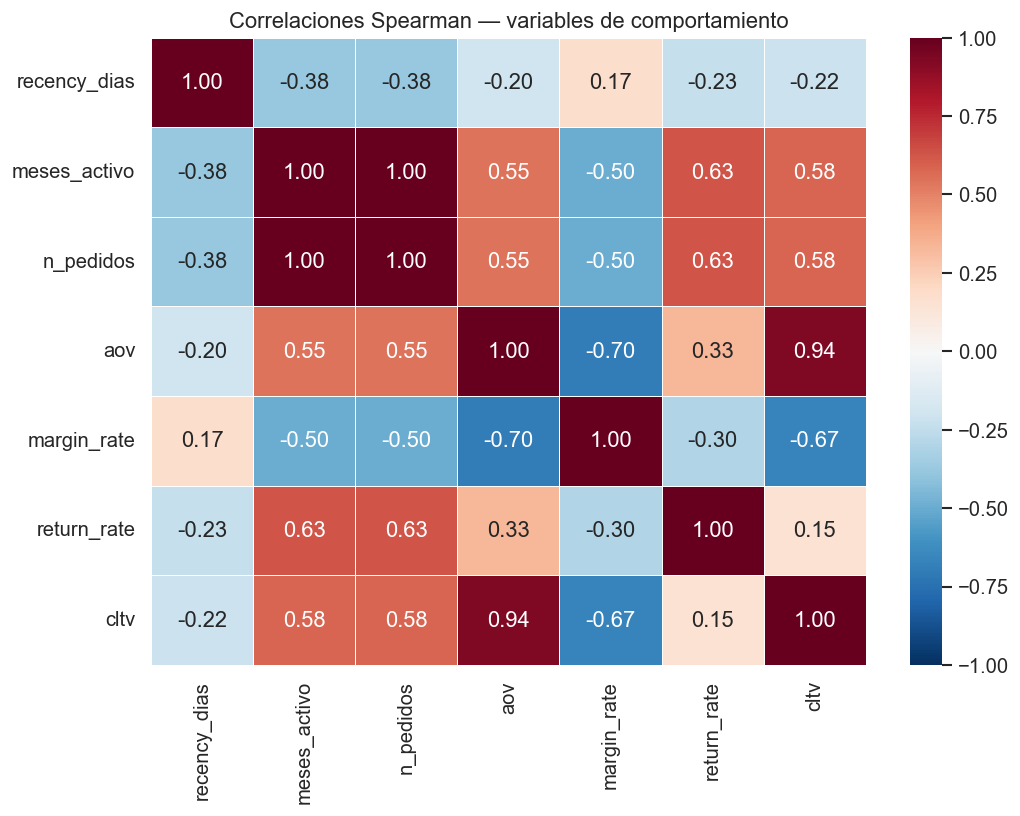

Correlaciones Spearman con CLTV (ordenadas por |r|):
  aov                 r = +0.9375
  margin_rate         r = -0.6658
  n_pedidos           r = +0.5847
  meses_activo        r = +0.5844
  recency_dias        r = -0.2150
  return_rate         r = +0.1501


In [12]:
features = ['recency_dias', 'meses_activo', 'n_pedidos',
            'aov', 'margin_rate', 'return_rate', 'cltv']

corr = df[features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlaciones Spearman — variables de comportamiento')
plt.tight_layout()
guardar_figura('5_3_spearman.png')
plt.show()

print("Correlaciones Spearman con CLTV (ordenadas por |r|):")
cltv_corr = corr['cltv'].drop('cltv').sort_values(key=abs, ascending=False)
for var, r in cltv_corr.items():
    print(f"  {var:<18}  r = {r:+.4f}")

### Hallazgos Seccion 3

Justificacion de Spearman: skewness CLTV = 2,57 (Sec. 1), excess kurtosis
5,37, y bimodalidad confirmada visualmente. Pearson asume normalidad y
linealidad, ambas violadas.

Correlaciones mas fuertes con CLTV (orden por |ρ|):

- **AOV: ρ = 0,94** — el AOV es practicamente equivalente al CLTV en ranking.
  Coherente con la identidad algebraica de Fase 5: CLTV = AOV × margin_rate ×
  n_pedidos. Como n_pedidos = 1 en el 75% del dataset, AOV y CLTV se vuelven
  casi sinonimos en ese subgrupo.
- **margin_rate: ρ = −0,67** — correlacion NEGATIVA fuerte. Los clientes con
  CLTV mas alto tienen tasa de margen relativa MENOR. Hipotesis: los recurrentes
  compran productos de mayor volumen/precio pero menor margen porcentual; los
  transaccionales compran productos sueltos con mayor margen relativo. Hallazgo
  de negocio.
- **meses_activo y n_pedidos: ρ = 0,58** con CLTV; entre si ρ = 1,00. La
  identidad freq_mensual × meses_activo = n_pedidos se refleja como correlacion
  perfecta.
- **return_rate: ρ = 0,15** con CLTV — sorprendentemente bajo. Las devoluciones
  no discriminan entre clientes valiosos y no valiosos.

Implicacion para Fase 6: AOV, margin_rate, meses_activo y return_rate son las
features con varianza independiente utiles para PCA. n_pedidos es redundante
con meses_activo (ρ = 1,00) — usar solo una.

## Seccion 4 — Analisis geografico

Agregacion por `distrito` para detectar heterogeneidad geografica en CLTV
y return_rate. Los resultados alimentan el analisis de Fase 6 si se incorpora
`zona_id` como feature categorica.

Distritos: 16

           distrito  n_clientes  cltv_total  cltv_medio  return_rate_medio
             Centro        1367  1023694.37  748.862012           0.070587
          Hortaleza         517   664617.71 1285.527485           0.052461
    Moncloa-Aravaca         222   198524.96  894.256577           0.061623
San Blas-Canillejas         216   185221.37  857.506343           0.043064
          Vicálvaro         193   171747.44  889.883109           0.037957
            Barajas         194   156976.16  809.155464           0.055480
             Retiro         723   152927.16  211.517510           0.070746
        Carabanchel         206   143864.56  698.371650           0.070898
          Chamartín         216   141476.36  654.983148           0.063683
 Puente de Vallecas         221   138711.24  627.652670           0.078172
              Usera         196   135541.39  691.537704           0.089638
          Salamanca         668   128532.76  192.414311           0.068024
Fuencarral

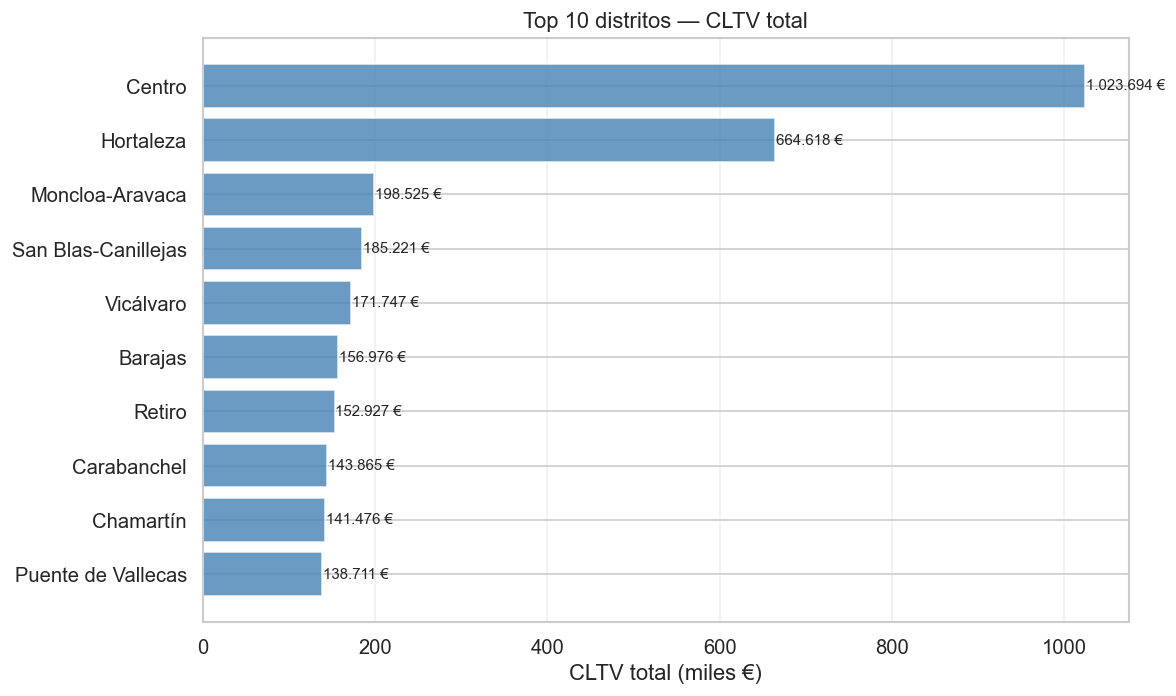

In [13]:
# ── Agregacion por distrito ───────────────────────────────────────────────────
geo = (
    df.groupby('distrito')
    .agg(
        n_clientes        = ('customer_id',  'count'),
        cltv_total        = ('cltv',         'sum'),
        cltv_medio        = ('cltv',         'mean'),
        return_rate_medio = ('return_rate',  'mean'),
    )
    .reset_index()
    .sort_values('cltv_total', ascending=False)
)

print(f"Distritos: {len(geo)}")
print()
print(geo.to_string(index=False))

# ── Top 10 por CLTV total ─────────────────────────────────────────────────────
top10 = geo.head(10).sort_values('cltv_total')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['distrito'], top10['cltv_total'] / 1000,
               color='steelblue', alpha=0.8)
ax.set_xlabel('CLTV total (miles €)')
ax.set_title('Top 10 distritos — CLTV total')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, top10['cltv_total']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            fmt_eur(val, 0), va='center', fontsize=9)
plt.tight_layout()
guardar_figura('5_4_geo_top10.png')
plt.show()

### Hallazgos Seccion 4

- **16 distritos** activos con clientes.
- **Heterogeneidad geografica**: la concentracion total no se reparte
  proporcionalmente. Centro lidera en CLTV total (1,02 M€) por volumen de
  clientes (1 367) pero su CLTV medio es bajo (749 €). Hortaleza, con apenas
  517 clientes, genera 665 k€ por su CLTV medio alto (1 286 €, el mas alto
  del dataset).
- **Distritos de alto valor por cliente**: Hortaleza (1 286 €), Moncloa-Aravaca
  (894 €), Vicalvaro (890 €), San Blas-Canillejas (858 €). Indican zonas con
  clientes recurrentes (modo alto) sobrerrepresentados.
- **Distritos masivos pero de bajo valor medio**: Salamanca (668 clientes,
  192 €/cliente) y Retiro (723 clientes, 211 €/cliente). Indican zonas con
  clientes mayoritariamente transaccionales (modo bajo) sobrerrepresentados.
- **Return rate por zona**: rango 3,8% (Vicalvaro) a 10,8% (Tetuan). Diferencia
  notable; posible factor para analisis de retencion geografica.
- **Implicacion para Fase 6**: la heterogeneidad en CLTV medio por distrito
  justifica incorporar `zona_id` como feature categorica en el clustering.